In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("1-studyhours.csv")
df


,Study Hours,Exam Score
0,3.9,40.0
1,9.6,57.1
2,4.5,42.7
3,11.4,65.1
4,14.4,78.7
5,18.0,78.8
6,19.2,77.1
7,22.2,90.8
8,25.2,99.0
9,17.4,84.6


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Study Hours  33 non-null     float64
 1   Exam Score   33 non-null     float64
dtypes: float64(2)
memory usage: 660.0 bytes


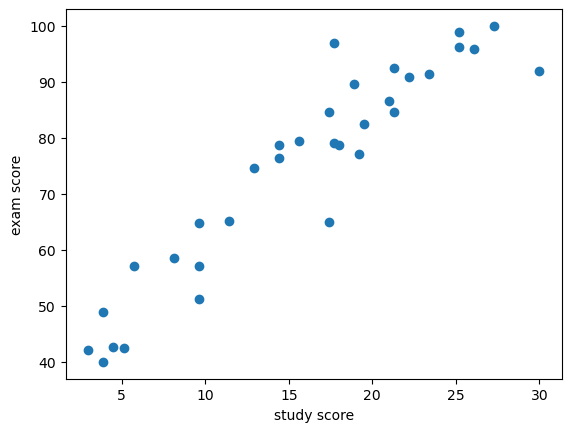

In [4]:
plt.scatter(df["Study Hours"],df["Exam Score"])
plt.xlabel("study score")
plt.ylabel("exam score")
plt.show()

In [5]:
# indipendent and dependent features 
X=df[["Study Hours"]]  #bizim bunu dataframe olması lazım özellikle x tarafının çünkü bursda birden çok geleceğini varsayar birden çok girdi girdiğimizde otomatik olarsk dataframe algılar ama tek bir değişken girdiğimizde dataframe yapmamız lazım
y=df["Exam Score"] #bu taraf da normal olarak seriesde kalması lazım çünkü burada bir çıktımız olacak zaten

In [6]:
type(X)


pandas.core.frame.DataFrame

In [7]:
type(y)

pandas.core.series.Series

In [8]:
#test ve train split nasıl bir dataset alırsak alalım ml için bir formül oluştururken bir kısmını eğitim bir kısmını da test kısmına alırız burada eğittiklerimizi test edeceğiz 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=15)

In [9]:
y_train

18     64.9
1      57.1
2      42.7
32     89.6
6      77.1
3      65.1
29     82.4
26     64.8
9      84.6
4      78.7
28     79.1
10     92.4
27     79.5
13    100.0
17     74.7
15     97.0
22     76.5
31     96.2
11     95.9
7      90.8
0      40.0
23     42.2
5      78.8
12     92.0
21     58.5
8      99.0
Name: Exam Score, dtype: float64

In [10]:
y_test

25    42.4
14    86.6
30    91.5
16    57.2
24    51.2
20    49.0
19    84.7
Name: Exam Score, dtype: float64

In [11]:
X_train

,Study Hours
18,17.4
1,9.6
2,4.5
32,18.9
6,19.2
3,11.4
29,19.5
26,9.6
9,17.4
4,14.4


In [12]:
#standardize the dataset
#bak: normalization vs standardization 
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler() #kolonlar arası büyük değer farklılıkların giderilmesi için

In [13]:
X_train=scaler.fit_transform(X_train) #z formülünü uyguluyor Xstd= (Xi - ortalama)/standart sapma
X_test=scaler.transform(X_test) #burada fit transform değil de transform dememizin nedeni data sızınıtısı yani leakega olmaması burada tarinle ilgili bir şey bilinmemesi için
X_train

array([[ 0.11794385],
       [-0.97424848],
       [-1.68837424],
       [ 0.32798083],
       [ 0.36998823],
       [-0.7222041 ],
       [ 0.41199563],
       [-0.97424848],
       [ 0.11794385],
       [-0.30213013],
       [ 0.15995124],
       [ 0.66404001],
       [-0.13410054],
       [ 1.50418796],
       [-0.51216711],
       [ 0.15995124],
       [-0.30213013],
       [ 1.21013618],
       [ 1.33615837],
       [ 0.7900622 ],
       [-1.77238903],
       [-1.89841122],
       [ 0.20195864],
       [ 1.88225453],
       [-1.18428547],
       [ 1.21013618]])

In [14]:
X_test

array([[-1.60435944],
       [ 0.62203261],
       [ 0.95809179],
       [-1.52034465],
       [-0.97424848],
       [-1.77238903],
       [ 0.66404001]])

In [15]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train,y_train)


LinearRegression()

In [ ]:
print("coef: ",regression.coef_)
print("intecept",regression.intercept_)

# yani bu ne demek denklem = 16x+76
#yani hiç çalışmaz bir saat çalışırsak 92 alıyoruzx imiz çalışma süremiz

coef:  [16.17860223]
intecept 76.9076923076923


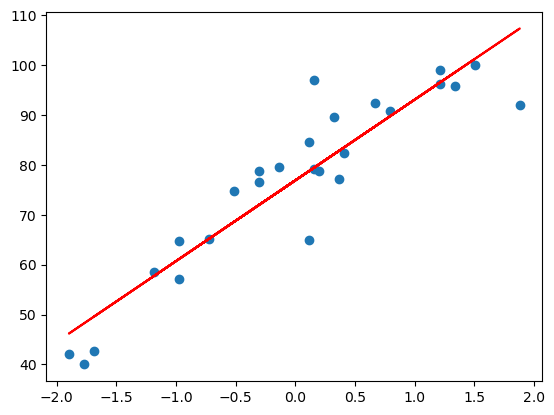

In [18]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),"r")

In [ ]:
#20 saat çalışan kaç alır
regression.predict(scaler.transform([[20]]))


c:\Users\parsk\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([84.70590731])

In [ ]:
#prediction with test data
y_pred_test=regression.predict(X_test)



In [ ]:
y_test

25    42.4
14    86.6
30    91.5
16    57.2
24    51.2
20    49.0
19    84.7
Name: Exam Score, dtype: float64

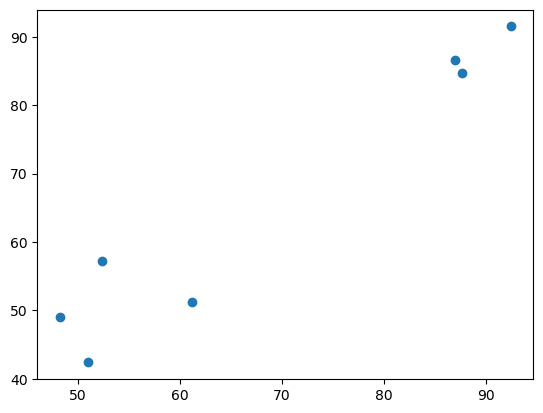

In [25]:
plt.scatter(y_pred_test,y_test)
plt.show()

In [28]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred_test)
mae=mean_absolute_error(y_test,y_pred_test)
rmse=np.sqrt(mse)
print("mse: ",mse)
print("mae: ",mae)
print("rmse: ",rmse)

mse:  29.458390488333936
mae:  4.054868128856141
rmse:  5.427558427906045


In [29]:
r2=r2_score(y_test,y_pred_test)
print("r2: ",r2)

r2:  0.9196596206825491
